# Prepare WGS data for the GWAS notebook

Genotype-side prep for the WGS pipeline: build the candidate-region VCF for the two GWAS
genes (`MSH3`, `PMS2`) and the ancestry PCA + kinship table, so
[`WGS_XDP_02_run_GWAS.ipynb`](WGS_XDP_02_run_GWAS.ipynb) can load them directly instead of
rebuilding them inline. Mirrors the GSA split
(`GSA_XDP_01_prepare_for_GWAS.ipynb` / `GSA_XDP_02_run_GWAS.ipynb`) and is the same logic as
`metric_corr_with_GWAS_only_diseased_XDP.ipynb` (cells covering VCF setup through kinship),
just split out so it doesn't have to re-run every time the phenotype/regression side changes.

Source data:

GWS: gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/vcfs/xdp/McCarroll_Macosko_XDP_WGS_20240501.donors_renamed_filtered_norm_cleaned.vcf.gz

GLS: gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/vcfs/xdp/xdp_post_mocha_impute_v2_rename_filtered.vcf.gz

trait ~ allele_dosage + PCs + sex + Age + d1d2_z2_cov


## Config

In [1]:
import subprocess, os
import pandas as pd

VCF_FOLDER = "/home/gdallagl/myworkdir/XDP/data/XDP/vcf"
MOUNT = VCF_FOLDER

IMAGE_BCFTOOLS = "quay.io/biocontainers/bcftools:1.21--h8b25389_0"
IMAGE_PLINK    = "quay.io/biocontainers/plink2:2.0.0a.6.9--h9948957_0"
N_THREADS = 16  # bcftools/plink2 both support multithreading

RAW_VCF  = "whole_xdp_norm/McCarroll_Macosko_XDP_WGS_20240501.donors_renamed_filtered_norm_cleaned.vcf.gz"
RAW_TBI  = "whole_xdp_norm/McCarroll_Macosko_XDP_WGS_20240501.donors_renamed_filtered_norm_cleaned.vcf.gz.tbi"

NORM_VCF = "whole_xdp_norm/McCarroll_Macosko_XDP_WGS_20240501.donors_renamed_filtered_norm_cleaned.vcf.gz"
NORM_TBI = "whole_xdp_norm/McCarroll_Macosko_XDP_WGS_20240501.donors_renamed_filtered_norm_cleaned.vcf.gz.tbi"

GENES_BED = ["MSH3", "PMS2"]  # "PDE8B"]
BED = "subset/genes.bed"
GENOME = "GRCh38"
FLANK = 20000  # +/-20 kb around each gene (regulatory + nearby modifier variants)

# Format toggle for the candidate-region pipeline: switches bcftools/plink2 between text VCF and binary BCF.
# BCF skips text encode/decode (faster read/write); this is the single place controlling it so the
# -O flag, index type, and plink2 input flag can never drift out of sync with each other.
TYPE = "bcf"  # "vcf" or "bcf"
EXT              = {"vcf": "vcf.gz", "bcf": "bcf"}[TYPE]
IDX_EXT          = {"vcf": "tbi", "bcf": "csi"}[TYPE]
BCFTOOLS_OFLAG   = {"vcf": "-Oz", "bcf": "-Ob"}[TYPE]
BCFTOOLS_IDXFLAG = {"vcf": "-t", "bcf": ""}[TYPE]        # -t forces TBI (VCF-only); omit for BCF -> defaults to CSI
PLINK_INFLAG     = {"vcf": "--vcf", "bcf": "--bcf"}[TYPE]

SUBSET_VCF = f"subset/candidate.{EXT}"
SUBSET_NORM_VCF = f"subset/candidate.norm.{EXT}"
SUBSET_NORM_IDX = f"subset/candidate.norm.{EXT}.{IDX_EXT}"

PCA_FOLDER = "whole_xdp_PCA"
N_PCs = 10

FASTA     = "fasta_genome/GRCh38.fasta"
LRLD_FILE = "fasta_genome/long_range_ld_GRCh38.txt"

os.makedirs(f"{VCF_FOLDER}/subset", exist_ok=True)
os.makedirs(f"{VCF_FOLDER}/{PCA_FOLDER}", exist_ok=True)

def bcftools(args, check=True):
    cmd = ["podman", "run", "--rm", "-w", "/data", "-v", f"{MOUNT}:/data", IMAGE_BCFTOOLS, "bcftools", *args]
    p = subprocess.run(cmd, capture_output=True, text=True)
    if check and p.returncode != 0:
        raise RuntimeError(f"bcftools {' '.join(args)} failed:\n{p.stderr}")
    return p.stdout, p.stderr

def bcftools_index(path):
    # BCFTOOLS_IDXFLAG is "" for BCF (bcftools defaults to CSI); avoid passing an empty argv element.
    args = ["index"] + ([BCFTOOLS_IDXFLAG] if BCFTOOLS_IDXFLAG else []) + ["-f", path]
    return bcftools(args)

def plink2(args, check=True):
    cmd = ["podman", "run", "--rm", "-w", "/data", "-v", f"{MOUNT}:/data", IMAGE_PLINK, "plink2", *args]
    p = subprocess.run(cmd, capture_output=True, text=True)
    print(p.stdout[-2000:])
    if check and p.returncode != 0:
        raise RuntimeError(f"plink2 {' '.join(args)} failed:\n{p.stderr}")
    return p.stdout, p.stderr


## Sanity-check the WGS VCF

In [2]:
# 1) sample count
out, err = bcftools(["query", "-l", NORM_VCF])
print("samples:", len(out.split()))

# 2) site count
out, err = bcftools(["index", "-n", NORM_VCF])
print("sites:", out.strip())

# 3) INFO/FORMAT fields
out, err = bcftools(["view", "-h", NORM_VCF])
print("\n".join(l for l in out.splitlines() if l.startswith(("##INFO", "##FORMAT"))))


samples: 31
sites: 2121337
##INFO=<ID=AC,Number=A,Type=Integer,Description="Allele count in genotypes, for each ALT allele, in the same order as listed">
##INFO=<ID=AF,Number=A,Type=Float,Description="Allele Frequency, for each ALT allele, in the same order as listed">
##INFO=<ID=AN,Number=1,Type=Integer,Description="Total number of alleles in called genotypes">
##INFO=<ID=AS_BaseQRankSum,Number=A,Type=Float,Description="allele specific Z-score from Wilcoxon rank sum test of each Alt Vs. Ref base qualities">
##INFO=<ID=AS_FS,Number=A,Type=Float,Description="allele specific phred-scaled p-value using Fisher's exact test to detect strand bias of each alt allele">
##INFO=<ID=AS_InbreedingCoeff,Number=A,Type=Float,Description="Allele-specific inbreeding coefficient as estimated from the genotype likelihoods per-sample when compared against the Hardy-Weinberg expectation">
##INFO=<ID=AS_MQ,Number=A,Type=Float,Description="Allele-specific RMS Mapping Quality">
##INFO=<ID=AS_MQRankSum,Number=

## Step 1 — Donor IDs known to the snRNA-seq side

Only need `adata.obs` metadata here (donor id / condition / sex) -- the
cell-type/trait computation itself lives in `WGS_XDP_02_run_GWAS.ipynb`.

In [3]:
import scanpy as sc

adata = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_+_NucSeq.h5ad", backed="r")

donors_from_adata_nucseq = adata[adata.obs["dataset"] == "nucseq"].obs["original_donor_id"].unique().tolist()
print(f"{len(donors_from_adata_nucseq)} nucseq donors: {donors_from_adata_nucseq}")

donors_from_adata_nucseq_male_diseased = adata[
    (adata.obs["dataset"] == "nucseq") &
    (adata.obs["condition"] == "XDP") &
    (adata.obs["sex"] == "M")
].obs["original_donor_id"].unique().tolist()
print(f"\n{len(donors_from_adata_nucseq_male_diseased)} male+XDP nucseq donors: {donors_from_adata_nucseq_male_diseased}")


47 nucseq donors: ['SCF-20-025', 'SCF-22-054CM', 'SCF-19-009', 'SCF-18-006', 'SCF_20-024', 'SCF_22-043', 'SCF-18-003', 'SCF-19-018', 'SCF-19-014', 'SCF-21-030', 'PCMC-16-011', 'SCF-22-058CF', 'SCF-18-004', 'SCF-20-023', 'SCF_21-037CM2', 'SCF-23-068CM', 'PCMC-16-012', 'SCF_23_070_MMC', 'SCF_21_027', 'SCF_21_038', 'SCF_21_029', 'SCF_21_032', 'SCF_22_049CCF', 'SCF_22_063CM', 'SCF_23_074CF', 'SCF_21_041', 'SCF_21_034', 'SCF_22_067CM', 'SCF_23_079CF', 'SCF_22_065CM', 'SCF_23_075CM', 'SCF_23_072CF', 'SCF_22-050CM6', 'SCF_22-048', 'SCF_20-026', 'SCF_22-046CF', 'SCF_22-057CM', 'SCF_22-056CF', 'SCF-22-045', 'SCF_23-081CM', 'SCF-22-044', 'SCF-19-020', 'SCF-22-042', 'SCF_22-052', 'SCF_23-083', 'SCF_22-060', 'SCF_23-080']

29 male+XDP nucseq donors: ['SCF-20-025', 'SCF-19-009', 'SCF-18-006', 'SCF_20-024', 'SCF_22-043', 'SCF-18-003', 'SCF-19-018', 'SCF-19-014', 'SCF-21-030', 'SCF-18-004', 'SCF-20-023', 'PCMC-16-012', 'SCF_23_070_MMC', 'SCF_21_027', 'SCF_21_038', 'SCF_21_029', 'SCF_21_032', 'SCF_21_

## Step 2 — Check chromosome naming

Must match the `.bed` file below -- ATTENTION: GRCh38 == assembly=38.

In [4]:
out, _ = bcftools(["view", "-h", NORM_VCF])
contig_lines = [l for l in out.splitlines() if l.startswith("##contig")]
print("\n".join(contig_lines[:10]))


##contig=<ID=1,length=248956422>
##contig=<ID=2,length=242193529>
##contig=<ID=3,length=198295559>
##contig=<ID=4,length=190214555>
##contig=<ID=5,length=181538259>
##contig=<ID=6,length=170805979>
##contig=<ID=7,length=159345973>
##contig=<ID=8,length=145138636>
##contig=<ID=9,length=138394717>
##contig=<ID=10,length=133797422>


## Step 3 — Build BED file for candidate genes

A BED file defines genomic windows to extract from the VCF.
Each row = one region: chrom  start(0-based)  end(1-based)  name.
We add +/-FLANK bp around each gene to capture regulatory and nearby variants.

In [5]:
import requests

def gene_coords(symbol, build="GRCh38"):
    """Query the Ensembl REST API for a gene's genomic coordinates."""
    server = ("https://rest.ensembl.org" if build == "GRCh38"
              else "https://grch37.rest.ensembl.org")
    r = requests.get(
        f"{server}/lookup/symbol/homo_sapiens/{symbol}",
        headers={"Content-Type": "application/json"}
    )
    r.raise_for_status()
    d = r.json()
    return d["seq_region_name"], d["start"], d["end"], d["assembly_name"]

rows = []
for g in GENES_BED:                               # GENES_BED = ["MSH3", "PMS2"]
    chrom, start, end, asm = gene_coords(g, GENOME)
    assert asm.startswith(GENOME), f"{g}: API returned {asm}, expected {GENOME}"
    # BED is 0-based half-open; Ensembl uses 1-based closed -> subtract 1 from start
    rows.append({
        "gene":  g,
        "chrom": "" + chrom,  # ATTENTION: WGS contigs are bare ("5", not "chr5") -- checked above
        "start": max(0, start - 1 - FLANK),
        "end":   end + FLANK,
    })

df_bed = (pd.DataFrame(rows)
            .sort_values(["chrom", "start"])
            .reset_index(drop=True))

df_bed[["chrom", "start", "end", "gene"]].to_csv(
    f"{VCF_FOLDER}/{BED}", sep="\t", header=False, index=False
)
print(f"BED file written -> {VCF_FOLDER}/{BED}")
df_bed


BED file written -> /home/gdallagl/myworkdir/XDP/data/XDP/vcf/subset/genes.bed


,gene,chrom,start,end
0,MSH3,5,80634612,80900295
1,PMS2,7,5950924,6029130


## Step 4 — Match donors between snRNA-seq and the VCF

Exact-string intersection: donor IDs in `adata` and in the VCF sample list are
supposed to use the same convention already (this WGS VCF was pre-renamed to
match), so unlike the GSA cohort this doesn't need ID normalization -- but the
check below still flags anything that doesn't line up.

In [6]:
out, _ = bcftools(["query", "-l", NORM_VCF])
samples_in_vcf = out.split()

print(f"Donors from adata nucseq {len(donors_from_adata_nucseq)}: {donors_from_adata_nucseq}")
print(f"Donors from adata nucseq male diseased {len(donors_from_adata_nucseq_male_diseased)}: {donors_from_adata_nucseq_male_diseased}")
print(f"Samples in VCF {len(samples_in_vcf)}: {samples_in_vcf}")

# Exact-match intersection: only donors whose IDs are identical in both files
samples_intersection = sorted(set(donors_from_adata_nucseq_male_diseased) & set(samples_in_vcf))
print(f"Exact-match intersection:           {len(samples_intersection)}")
print("\nMatched donors:"); print(samples_intersection)

# Check for donors in adata but NOT in VCF (possible ID format issue)
not_present_in_adata = set(samples_in_vcf) - set(donors_from_adata_nucseq_male_diseased)
if not_present_in_adata:
    print(f"\nDonors in VCF but NOT in adata_male_diseased ({len(not_present_in_adata)}): {sorted(not_present_in_adata)}")
    print("-> Check for suffix/underscore differences in VCF sample names above")


Donors from adata nucseq 47: ['SCF-20-025', 'SCF-22-054CM', 'SCF-19-009', 'SCF-18-006', 'SCF_20-024', 'SCF_22-043', 'SCF-18-003', 'SCF-19-018', 'SCF-19-014', 'SCF-21-030', 'PCMC-16-011', 'SCF-22-058CF', 'SCF-18-004', 'SCF-20-023', 'SCF_21-037CM2', 'SCF-23-068CM', 'PCMC-16-012', 'SCF_23_070_MMC', 'SCF_21_027', 'SCF_21_038', 'SCF_21_029', 'SCF_21_032', 'SCF_22_049CCF', 'SCF_22_063CM', 'SCF_23_074CF', 'SCF_21_041', 'SCF_21_034', 'SCF_22_067CM', 'SCF_23_079CF', 'SCF_22_065CM', 'SCF_23_075CM', 'SCF_23_072CF', 'SCF_22-050CM6', 'SCF_22-048', 'SCF_20-026', 'SCF_22-046CF', 'SCF_22-057CM', 'SCF_22-056CF', 'SCF-22-045', 'SCF_23-081CM', 'SCF-22-044', 'SCF-19-020', 'SCF-22-042', 'SCF_22-052', 'SCF_23-083', 'SCF_22-060', 'SCF_23-080']
Donors from adata nucseq male diseased 29: ['SCF-20-025', 'SCF-19-009', 'SCF-18-006', 'SCF_20-024', 'SCF_22-043', 'SCF-18-003', 'SCF-19-018', 'SCF-19-014', 'SCF-21-030', 'SCF-18-004', 'SCF-20-023', 'PCMC-16-012', 'SCF_23_070_MMC', 'SCF_21_027', 'SCF_21_038', 'SCF_21_02

## Step 5 — Subset to gene windows + matched donors, rename chromosomes, normalize

In [7]:
# Extract only the genomic windows defined in the BED file and only the donors present in the intersection.
bcftools(["view",
          "-R", BED,                               # restrict to gene windows
          "-s", ",".join(samples_intersection),     # restrict to our donors
          "--threads", str(N_THREADS),
          NORM_VCF,                                 # input (normalized whole-cohort VCF)
          BCFTOOLS_OFLAG, "-o", SUBSET_VCF])
print(f"Subset written -> {SUBSET_VCF}")


Subset written -> subset/candidate.bcf


In [8]:
# Rename chromosomes Ensembl->UCSC so they match the FASTA (VCF contigs are named "5","7" etc.;
# the reference FASTA uses "chr5","chr7" -- bcftools norm -f will fail unless the naming matches).
SUBSET_VCF_UCSC = f"subset/candidate.ucsc.{EXT}"

chrom_map_path = f"{VCF_FOLDER}/subset/chrom_rename.txt"
with open(chrom_map_path, "w") as fh:
    for c in [*range(1, 23), "X", "Y", "MT"]:
        fh.write(f"{c}\tchr{c}\n")

bcftools(["annotate", "--rename-chrs", "subset/chrom_rename.txt",
          "--threads", str(N_THREADS),
          SUBSET_VCF, BCFTOOLS_OFLAG, "-o", SUBSET_VCF_UCSC])
bcftools_index(SUBSET_VCF_UCSC)


('', '')

In [9]:
# Re-normalise the subsetted VCF: left-align + use reference for complex indels, split multi-allelic records
bcftools(["norm", "-f", FASTA, "-m", "-any", "--threads", str(N_THREADS),
          SUBSET_VCF_UCSC, BCFTOOLS_OFLAG, "-o", SUBSET_NORM_VCF])
bcftools_index(SUBSET_NORM_VCF)

n_sites, _ = bcftools(["index", "-n", SUBSET_NORM_VCF])
print(f"Candidate-region sites after norm: {n_sites.strip()}")
print(f"\n-> ready for WGS_XDP_02_run_GWAS.ipynb's plink2 conversion step:")
print(f'   SUBSET_NORM_VCF = "{SUBSET_NORM_VCF}"   PLINK_INFLAG = "{PLINK_INFLAG}"')


Candidate-region sites after norm: 234

-> ready for WGS_XDP_02_run_GWAS.ipynb's plink2 conversion step:
   SUBSET_NORM_VCF = "subset/candidate.norm.bcf"   PLINK_INFLAG = "--bcf"


## Step 6 — Ancestry PCA (full XDP WGS cohort)

PCA is computed on **all donors in the XDP WGS VCF** (not just those with
snRNA-seq data) to get stable ancestry estimates. PC1-PC3 are then used as
covariates in the GWAS to correct for population structure.

Pipeline:
1. Convert full VCF -> plink2 (autosomes only)
2. QC: MAF >= 5 %, geno <= 5 %
3. Exclude known long-range LD regions + LD-prune to independent SNPs
4. Compute 10 PCs

In [10]:
# PCA is computed on the FULL XDP WGS cohort (all donors in the VCF), not just those with
# phenotype data. This gives more stable PC estimates.
PCA_PGEN        = f"{PCA_FOLDER}/vcf_pca"          # pgen from all autosome variants
PCA_PGEN_QC     = f"{PCA_FOLDER}/vcf_pca_qc"      # pgen after MAF + geno filters
PCA_PGEN_PRUNED = f"{PCA_FOLDER}/vcf_pca_pruned"  # prefix for prune.in / prune.out
PCA_OUT         = f"{PCA_FOLDER}/PCA"              # final PCA output prefix

print("Converting full XDP VCF to plink...")
plink2(["--vcf", NORM_VCF,
        "--autosome",  # exclude chrX, chrY, chrM; sex/MT chromosomes distort PCA
        "--set-all-var-ids", "@:#:$r:$a",
        "--new-id-max-allele-len", "100", "missing",
        "--make-pgen", "--out", PCA_PGEN, "--threads", str(N_THREADS)])

print("\nQC for PCA...")
plink2(["--pfile", PCA_PGEN,
        "--geno", "0.05",  # drop variants missing in >5% of samples
        "--maf", "0.05",   # drop variants with minor allele frequency < 5%
        "--make-pgen", "--out", PCA_PGEN_QC, "--threads", str(N_THREADS)])


Converting full XDP VCF to plink...
.
--vcf: 1638k variants converted.
--vcf: 1703k variants converted.
--vcf: 1769k variants converted.
--vcf: 1835k variants converted.
--vcf: 1900k variants converted.
--vcf: 1966k variants converted.
--vcf: 2031k variants converted.
--vcf: 2097k variants converted.
--vcf: whole_xdp_PCA/vcf_pca-temporary.pgen +
whole_xdp_PCA/vcf_pca-temporary.pvar.zst + whole_xdp_PCA/vcf_pca-temporary.psam
written.
31 samples (0 females, 0 males, 31 ambiguous; 31 founders) loaded from
whole_xdp_PCA/vcf_pca-temporary.psam.
2121337 variants loaded from whole_xdp_PCA/vcf_pca-temporary.pvar.zst.
Note: No phenotype data present.
Writing whole_xdp_PCA/vcf_pca.psam ... done.
Writing whole_xdp_PCA/vcf_pca.pvar ... 10101111121213131414151516161717181819192020212122222323242425252626272728282929303031313232333334343535363637373838393940404141424243434444454546464747484849495050515152525353545455555656575758585959606061616262636364646565666667676868696970707171727273737474757576

('PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/\n(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3\nLogging to whole_xdp_PCA/vcf_pca_qc.log.\nOptions in effect:\n  --geno 0.05\n  --maf 0.05\n  --make-pgen\n  --out whole_xdp_PCA/vcf_pca_qc\n  --pfile whole_xdp_PCA/vcf_pca\n  --threads 16\n\nStart time: Thu Jul 16 00:54:04 2026\n314189 MiB RAM detected, ~244531 available; reserving 157094 MiB for main\nworkspace.\nUsing up to 16 threads (change this with --threads).\n31 samples (0 females, 0 males, 31 ambiguous; 31 founders) loaded from\nwhole_xdp_PCA/vcf_pca.psam.\n2121337 variants loaded from whole_xdp_PCA/vcf_pca.pvar.\nNote: No phenotype data present.\nCalculating allele frequencies... 0%\x08\x083%\x08\x086%\x08\x089%\x08\x0812%\x08\x08\x0815%\x08\x08\x0818%\x08\x08\x0821%\x08\x08\x0824%\x08\x08\x0827%\x08\x08\x0830%\x08\x08\x0833%\x08\x08\x0837%\x08\x08\x0840%\x08\x08\x0843%\x08\x08\x0846%\x08\x08\x0849%\x08\x08\x0852%\x0

In [11]:
# From: https://raw.githubusercontent.com/meyer-lab-cshl/plinkQC/master/inst/extdata/high-LD-regions-hg38-GRCh38.txt
long_range_ld = """chr1 47761740 51761740 LRLD1
chr1 47761740 51761740 1
chr2 85919365 100517106 2
chr2 89917298 89917322 3
chr2 87416141 87416186 4
chr2 87417804 87417863 5
chr2 87418924 87418981 6
chr1 144106678 144106709 7
chr14 87391719 87391996 8
chr9 40365644 40365693 9
chr2 182427027 189427029 10
chr3 47483505 49987563 11
chr3 83368158 86868160 12
chr5 44464140 51168409 13
chr5 129636407 132636409 14
chr6 25391792 33424245 15
chr6 26726947 26726981 16
chr6 57788603 58453888 17
chr6 61109122 61357029 18
chr6 61424410 61424451 19
chr9 64198500 64200392 20
chr6 139637169 142137170 21
chr7 54964812 66897578 22
chr7 62182500 62277073 23
chr12 34639034 34639084 24
chr14 94658026 94658080 25
chr17 43159541 43159574 26
chr2 135275091 135275210 27
chr1 181955019 181955047 28
chr22 30060084 30060162 29
chr9 88958735 88959017 30
chr2 207609786 207609808 31
chr22 42980497 42980522 32
chr20 4031884 4032441 33
chr8 8105067 12105082 34
chr8 43025699 48924888 35
chr8 47303500 47317337 36
chr8 110918594 113918595 37
chr10 36671065 43184546 38
chr10 41693521 41885273 39
chr1 125169943 125170022 40
chr11 88127183 91127184 41
chr12 32955798 41319931 42
chr20 33948532 36438183 43
"""
with open(f"{VCF_FOLDER}/{LRLD_FILE}", "w") as f:
    f.write(long_range_ld)


In [12]:
# LD pruning -> produces {PCA_PGEN_PRUNED}.prune.in (the independent variant list)
print("LD pruning...")
plink2(["--pfile", PCA_PGEN_QC,
        "--maf", "0.05", "--geno", "0.02",
        "--hwe", "1e-6",           # remove variants deviating from Hardy-Weinberg equilibrium
        "--snps-only",             # keep only biallelic SNPs before running any other filter
        "--rm-dup", "exclude-all", # drop any variants sharing the same ID string
        "--bad-ld",                # "yes, I know N < 50, proceed anyway."
        "--exclude", "range", LRLD_FILE,      # remove the long-range LD blocks written above
        "--indep-pairwise", "200", "50", "0.2",  # window=200 variants, step=50, max r^2=0.2
        "--out", PCA_PGEN_PRUNED])

# Pre-compute allele frequencies (required because N=31 < 50 threshold)
print("\nComputing allele frequencies...")
plink2(["--pfile", PCA_PGEN_QC,
        "--extract", f"{PCA_PGEN_PRUNED}.prune.in",
        "--freq", "--out", PCA_OUT])

# Compute PCA using the pre-computed frequencies
print("\nComputing PCA...")
plink2(["--pfile", PCA_PGEN_QC,
        "--extract", f"{PCA_PGEN_PRUNED}.prune.in",
        "--maf", "0.05", "--geno", "0.02", "--hwe", "1e-6",
        "--read-freq", f"{PCA_OUT}.afreq",
        "--pca", str(N_PCs), "--out", PCA_OUT])


LD pruning...
PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to whole_xdp_PCA/vcf_pca_pruned.log.
Options in effect:
  --bad-ld
  --exclude range fasta_genome/long_range_ld_GRCh38.txt
  --geno 0.02
  --hwe 1e-6
  --indep-pairwise 200 50 0.2
  --maf 0.05
  --out whole_xdp_PCA/vcf_pca_pruned
  --pfile whole_xdp_PCA/vcf_pca_qc
  --rm-dup exclude-all
  --snps-only

Start time: Thu Jul 16 00:54:08 2026
314189 MiB RAM detected, ~244513 available; reserving 157094 MiB for main
workspace.
Using up to 48 threads (change this with --threads).
31 samples (0 females, 0 males, 31 ambiguous; 31 founders) loaded from
whole_xdp_PCA/vcf_pca_qc.psam.
1685274 out of 1936929 variants loaded from whole_xdp_PCA/vcf_pca_qc.pvar.
Note: No phenotype data present.
Note: Skipping --rm-dup since no duplicate IDs are present.
--exclude bed1: 48672 variants excluded.
Calculating allele frequencies.

('PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/\n(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3\nLogging to whole_xdp_PCA/PCA.log.\nOptions in effect:\n  --extract whole_xdp_PCA/vcf_pca_pruned.prune.in\n  --geno 0.02\n  --hwe 1e-6\n  --maf 0.05\n  --out whole_xdp_PCA/PCA\n  --pca 10\n  --pfile whole_xdp_PCA/vcf_pca_qc\n  --read-freq whole_xdp_PCA/PCA.afreq\n\nStart time: Thu Jul 16 00:54:10 2026\n314189 MiB RAM detected, ~244496 available; reserving 157094 MiB for main\nworkspace.\nUsing up to 48 threads (change this with --threads).\n31 samples (0 females, 0 males, 31 ambiguous; 31 founders) loaded from\nwhole_xdp_PCA/vcf_pca_qc.psam.\n1936929 variants loaded from whole_xdp_PCA/vcf_pca_qc.pvar.\nNote: No phenotype data present.\n--extract: 37816 variants remaining.\n--read-freq: PLINK 2 --freq file detected.\n\n--read-freq: Frequencies for 10k variants loaded.\n--read-freq: Frequencies for 20k variants loaded.\n--read-fr

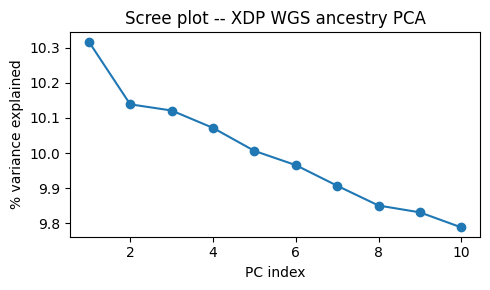

PC scores (first 5 donors):


,IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,PCMC-16-011,0.145423,-0.117074,0.220676,0.033199,0.082611,0.194314,0.086305,-0.002521,0.230084,-0.221438
1,PCMC-16-012,0.151813,-0.144165,0.161088,0.064444,-0.014435,0.067784,-0.065121,0.206288,0.068751,-0.099444
2,PCMC_17-005,0.078685,0.002348,0.151297,-0.005681,0.141958,0.126402,-0.420942,0.042715,-0.149866,-0.114692
3,PCMC_17-010,0.007593,-0.044759,-0.291861,0.037569,-0.201474,0.048006,0.246662,-0.051078,-0.146609,0.041620
4,PCMC_17-012,0.042215,-0.052705,0.072862,0.522853,0.054095,0.144296,0.062331,0.212627,0.323961,0.240715



Variance explained:


,eigenval,PC,pct
0,1.06059,PC1,10.317023
1,1.04227,PC2,10.138813
2,1.04046,PC3,10.121206
3,1.03538,PC4,10.071790
4,1.02866,PC5,10.006420
5,1.02450,PC6,9.965953
6,1.01847,PC7,9.907296
7,1.01269,PC8,9.851070
8,1.01069,PC9,9.831615
9,1.00629,PC10,9.788813


In [13]:
import matplotlib.pyplot as plt

# plink2 writes a header starting with "#FID" -> strip the "#" to get clean column names.
pcs = pd.read_csv(f"{VCF_FOLDER}/{PCA_OUT}.eigenvec", sep=r"\s+")
pcs.columns = [c.lstrip("#") for c in pcs.columns]

eigenvals = pd.read_csv(f"{VCF_FOLDER}/{PCA_OUT}.eigenval", header=None, names=["eigenval"])
eigenvals["PC"]  = [f"PC{i+1}" for i in range(len(eigenvals))]
eigenvals["pct"] = eigenvals["eigenval"] / eigenvals["eigenval"].sum() * 100

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(range(1, len(eigenvals)+1), eigenvals["pct"], marker="o")
ax.set_xlabel("PC index"); ax.set_ylabel("% variance explained")
ax.set_title("Scree plot -- XDP WGS ancestry PCA")
plt.tight_layout(); plt.show()

print("PC scores (first 5 donors):"); display(pcs.head())
print("\nVariance explained:"); display(eigenvals)


In [14]:
"""
 All 31 donors are almost certainly from the same ethnic background -- there is no population structure to detect.

 Including PC1-PC3 as covariates adds random noise to the model, not ancestry correction
"""


'\n All 31 donors are almost certainly from the same ethnic background -- there is no population structure to detect.\n\n Including PC1-PC3 as covariates adds random noise to the model, not ancestry correction\n'

## Step 7 — Kinship removal

In [15]:
import networkx as nx

# Compute KING kinship from pruned variants
plink2(["--pfile", PCA_PGEN_QC,
        "--extract", f"{PCA_PGEN_PRUNED}.prune.in",
        "--make-king-table",
        "--king-table-filter", "0.0442",  # only print pairs with kinship > 2nd cousin threshold
        "--out", f"{PCA_FOLDER}/kinship"])

# Load pairs and greedily remove one from each
king = pd.read_csv(f"{VCF_FOLDER}/{PCA_FOLDER}/kinship.kin0", sep="\t")
king.columns = [c.lstrip("#") for c in king.columns]
display(king)

# Build graph: each node = sample, each edge = related pair
G = nx.Graph()
for _, row in king.iterrows():
    G.add_edge(row["IID1"], row["IID2"])

# Greedy: remove the node with most connections first
to_remove = set()
while G.number_of_edges() > 0:
    worst = max(G.nodes, key=lambda n: G.degree(n))
    to_remove.add(worst)
    G.remove_node(worst)
print(f"Samples to exclude: {to_remove}")

# Not applied here (same as the original monolithic notebook, which computed this list but left
# the exclusion commented out). WGS_XDP_02_run_GWAS.ipynb can filter df_gwas on `to_remove` if desired:
#   df_gwas = df_gwas[~df_gwas.index.isin(to_remove)]



Note: No phenotype data present.
--extract: 37816 variants remaining.
37816 variants remaining after main filters.
--make-king-table pass 1/1: Scanning for rare variants... 101316192325283134374043464952565962666973768084899397done.
0 variants handled by initial scan (37816 remaining).

--make-king-table pass 1/1: 0 variants complete.
--make-king-table pass 1/1: 1536 variants complete.
--make-king-table pass 1/1: 3072 variants complete.
--make-king-table pass 1/1: 4608 variants complete.
--make-king-table pass 1/1: 6144 variants complete.
--make-king-table pass 1/1: 7680 variants complete.
--make-king-table pass 1/1: 9216 variants complete.
--make-king-table pass 1/1: 10752 variants complete.
--make-king-table pass 1/1: 12288 variants complete.
--make-king-table pass 1/1: 13824 variants complete.
--make-king-table pass 1/1: 15360 variants complete.
--make-king-table pass 1/1: 16896 variants complete.
--make-king-table pass 1/1: 18432 variants complete.
--make-king-table pass 1/1: 1996

,IID1,IID2,NSNP,HETHET,IBS0,KINSHIP
0,SCF-21-030,SCF-20-023,37816,0.267083,0.103184,0.057098


Samples to exclude: {'SCF-21-030'}


## Outputs — what WGS_XDP_02_run_GWAS.ipynb loads

| Variable | Value | Produced by |
|---|---|---|
| `SUBSET_NORM_VCF` | `subset/candidate.norm.bcf` | Step 5 |
| `PLINK_INFLAG` | `--bcf` | Step 5 (`TYPE` toggle) |
| `PCA_OUT` | `whole_xdp_PCA/PCA` | Step 6 |
| kinship table | `whole_xdp_PCA/kinship.kin0` | Step 7 |

`to_remove` (Step 7) is a related-donor exclusion list, computed but not applied to any output
here — same as the original monolithic notebook. `WGS_XDP_02_run_GWAS.ipynb` can apply it to
`df_gwas` if desired.
